<a href="https://colab.research.google.com/github/navap3206-debug/hello-world/blob/main/T09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Using basic statistical properties of the variance, as well as singlevariable calculus, derive (5.6). In other words, prove that α given by
(5.6) does indeed minimize Var(αX + (1 − α)Y ).**

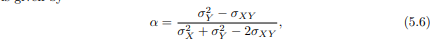

Sabiendo: $$f(\alpha) = \alpha^2\sigma_X^2 + (1 - \alpha)^2\sigma_Y^2 + 2\alpha(1 - \alpha)\sigma_{XY}$$
derivamos con respecto a alpha:
*    $\alpha^2\sigma_X^2$ -> $2\alpha\sigma_X^2$
*   $(1 - \alpha)^2\sigma_Y^2$  ->  $-2(1 - \alpha)\sigma_Y^2$
*   $2\alpha(1 - \alpha)\sigma_{XY}$  ->   $2(1 - 2\alpha)\sigma_{XY}$

tenenemos: $$f'(\alpha) = 2\alpha\sigma_X^2 - 2(1 - \alpha)\sigma_Y^2 + 2(1 - 2\alpha)\sigma_{XY}$$

igualamos a 0, dividimos entre 2 y factorizamos con respecto alpha:


$$\\ \alpha(\sigma_X^2 + \sigma_Y^2 - 2\sigma_{XY}) = \sigma_Y^2 - \sigma_{XY}$$

tenemos la expresión 5.6:
$$\alpha = \frac{\sigma_Y^2 - \sigma_{XY}}{\sigma_X^2 + \sigma_Y^2 - 2\sigma_{XY}}$$


2. We will now derive the probability that a given observation is part
of a bootstrap sample. Suppose that we obtain a bootstrap sample
from a set of n observations.

* (a) What is the probability that the first bootstrap observation is
not the jth observation from the original sample? Justify your
answer.
  *  Como bootstrap trabaja con remplazo siempre va a haber la misma probabilidad de sacar una muestra especifica y  de no sacarla (1-p)
$$P(x_1 \ne x_{jth}) = 1-\frac{1}{n}$$
* (b) What is the probability that the second bootstrap observation
is not the jth observation from the original sample?
 $$P(x_1 \ne x_{jth}) = 1-\frac{1}{n}$$
* (c) Argue that the probability that the jth observation is not in the
bootstrap sample is (1 − 1/n)n.
  * se tendría que realizar el intercepto de todos los eventos donde se cumpla $P(x_1 \ne x_{jth})$ así que sabiendo que son eventos independientes sería cuestión de mutiplicar todas la $n$ probabilidades de que no salga el evento lo que resulta: $$(1 − 1/n)^n$$
* (d) When n =5, what is the probability that the jth observation is
in the bootstrap sample?
  * sabiendo que buscamos el complemento de $(1 − 1/n)^n$ solo sustituimos:
$$1-(1-\frac{1}{5})^5 = 0.672$$
* (e) When n = 100, what is the probability that the jth observation
is in the bootstrap sample?
$$1-(1-\frac{1}{100})^{100} = 0.6339$$

* (f) When n = 10, 000, what is the probability that the jth observation is in the bootstrap sample?
$$1-(1-\frac{1}{10000})^{10000} = 0.6321$$

* (g) Create a plot that displays, for each integer value of n from 1
to 100, 000, the probability that the jth observation is in the
bootstrap sample. Comment on what you observe.


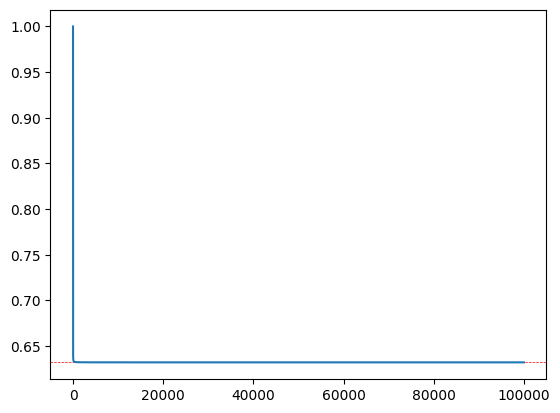

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
n = np.arange(1,100000)
p = 1-(1-1/n)**n
#agregare una linea en .632
plt.axhline(y=0.632, color='r', linestyle='--', linewidth=.5)

plt.plot(n, p)


* (h) We will now investigate numerically the probability that a bootstrap sample of size n = 100 contains the jth observation. Here
j =4. We first create an array store with values that will subsequently be overwritten using the function np.empty(). We then repeatedly create bootstrap samples, and each time we record
whether or not the fifth observation is contained in the bootstrap
sample.
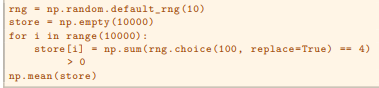

Comment on the results obtained.

In [12]:
rng = np.random.default_rng(10)
store = np.empty(1000000)
for i in range(1000000):
  store[i] = np.sum(rng.choice(100, size = 100,replace=True) == 4) >0
np.mean(store)

np.float64(0.634059)

La probabilidad de reecontrar la observación 4 converge en .63etc como lo demuestra la grafica

3. We now review k-fold cross-validation.
* (a) Explain how k-fold cross-validation is implemented.
  * K-fold crea un numero de muestras definidas conformados de forma aleatoria con nuestros datos permitiendo conocer el desempeño de nuestro modelo al generalizar.
* (b) What are the advantages and disadvantages of k-fold crossvalidation relative to:
  *  i. The validation set approach?
      *  Ventajas: Posees una estimación más fiel  de tus errores y metricos debido a que promedias distintos resultados; y a su vez posees menor sesgo debido a que entrenas con distintas distribuciones pero de forma significativa tal vez con el 90% de datos en un cv de 10.
      * Hay más costo computacional pero no es desmedido como LOOCV
  *  ii. LOOCV?
      * Te conviene el k-folds debido al alto costo computacional que requiere LOOCV osea entrenar n vecesa a comparación de las k veces de k-folds.
      * K-folds puede segarse más que LOOCV

4. Suppose that we use some statistical learning method to make a prediction for the response Y for a particular value of the predictor X.
Carefully describe how we might estimate the standard deviation of
our prediction.

    1- Realizas alguna estrategia de remuestreo y determinas tus conjuntos
    2- Entrenas con cada uno de los conjuntos
    3- COn cada modelo predice y almacena el reultado
    4- Y aplicas el error estandar (muestral):
    $$SE(\hat{y}) = \sqrt{\frac{1}{B-1} \sum_{b=1}^{B} \left(\hat{y}^{*b} - \bar{\hat{y}}^*\right)^2}$$

**5. In Chapter 4, we used logistic regression to predict the probability of
default using income and balance on the Default data set. We will
now estimate the test error of this logistic regression model using the
validation set approach. Do not forget to set a random seed before
beginning your analysis.**


(a) Fit a logistic regression model that uses income and balance to
predict default.

In [23]:
from google.colab import files
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

In [14]:
dt = files.upload()

Saving Default.csv to Default.csv


In [42]:
df = pd.read_csv('Default.csv')

In [43]:
df.head(1)

,default,student,balance,income
0,No,No,729.526495,44361.625074


<Axes: >

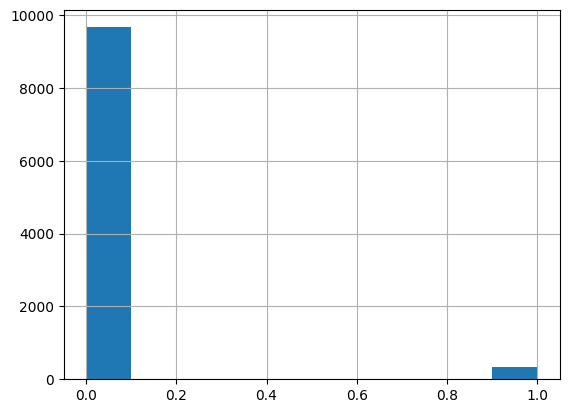

In [47]:
df['default'].hist()

In [46]:
df['default'] = (df['default'] == "Yes").astype(int)
df.head(1)

,default,student,balance,income
0,0,No,729.526495,44361.625074


i. Split the sample set into a training set and a validation set.


In [48]:
X = df[['income','balance']]
y = df['default']

In [49]:
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=42)

In [50]:
model = LogisticRegression()

ii.  Fit a multiple logistic regression model using only the training observations

In [51]:
model.fit(train_X,train_y)

LogisticRegression()

ii. Obtain a prediction of default status for each individual in
the validation set by computing the posterior probability of
default for that individual, and classifying the individual to
the default category if the posterior probability is greater
than 0.5.

In [60]:
ans = model.predict_proba(test_X)[:, 1]
ans

array([5.56435778e-02, 1.54779540e-03, 1.14555589e-05, ...,
       1.43597779e-05, 2.77535188e-02, 1.15705317e-04])

In [61]:
default_predict = (ans > .5 ).astype(int)

In [64]:
default_predict

array([0, 0, 0, ..., 0, 0, 0])

iv. Compute the validation set error, which is the fraction of
the observations in the validation set that are misclassified.

In [66]:
tasa_de_error = np.mean(default_predict != test_y)
tasa_de_error

np.float64(0.0305)

(c) Repeat the process in (b) three times, using three different splits
of the observations into a training set and a validation set. Comment on the results obtained

In [67]:
train_X2, test_X2, train_y2, test_y2 = train_test_split(X, y, test_size=0.2, random_state=88)
train_X3, test_X3, train_y3, test_y3 = train_test_split(X, y, test_size=0.2, random_state=21)

In [68]:
model2 = LogisticRegression()
model3 = LogisticRegression()
model2.fit(train_X2,train_y2)
model3.fit(train_X3,train_y3)

LogisticRegression()

In [70]:
default_predict2 = (model2.predict_proba(test_X2)[:,1] > .5 ).astype(int)
default_predict3 = (model3.predict_proba(test_X3)[:,1] > .5 ).astype(int)

In [71]:
tasa_de_error2 = np.mean(default_predict2 != test_y2)
tasa_de_error3 = np.mean(default_predict3 != test_y3)

In [72]:
print(tasa_de_error2)
print(tasa_de_error3)

0.025
0.0255


La tasa de error varía según la manera en la que los datos sean divididos

(d) Now consider a logistic regression model that predicts the probability of default using income, balance, and a dummy variable
for student. Estimate the test error for this model using the validation set approach. Comment on whether or not including a
dummy variable for student leads to a reduction in the test error
rate

In [78]:
df['student'] = (df['student'] == "Yes").astype(int)

In [79]:
X = df[['income','balance','student']]
y = df['default']


In [90]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [91]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [92]:
error_rate = np.mean(model.predict(X_test) != y_test)
error_rate

np.float64(0.0305)

En general después de probar con los 3 random states que se usaron, los errores se mantienen practicamente iguales, por lo que la variable student no aporta a la predicción.

**6. We continue to consider the use of a logistic regression model to
predict the probability of default using income and balance on the
Default data set. In particular, we will now compute estimates for the
standard errors of the income and balance logistic regression coefficients in two different ways: (1) using the bootstrap, and (2) using the
standard formula for computing the standard errors in the sm.GLM()
function. Do not forget to set a random seed before beginning your
analysis**

(a) Using the summarize() and sm.GLM() functions, determine the
estimated standard errors for the coefficients associated with
income and balance in a multiple logistic regression model that
uses both predictors.

In [106]:
#recursos necesarios
!pip install ISLP
import statsmodels.api as sm
from ISLP.models import summarize
import statsmodels.formula.api as smf

In [107]:
modelo = smf.logit('default ~ income + balance',df)

In [108]:
result = modelo.fit()
summarize(result)

Optimization terminated successfully.
         Current function value: 0.078948
         Iterations 10


,coef,std err,z,P>|z|
Intercept,-11.540500,0.435000,-26.544,0.0
income,0.000021,0.000005,4.174,0.0
balance,0.005600,0.000000,24.835,0.0


b) Write a function, boot_fn(), that takes as input the Default data
set as well as an index of the observations, and that outputs
the coefficient estimates for income and balance in the multiple
logistic regression model.

In [109]:
def boot_fn(data, index):
    #Filtramos los datos según los índices dados
    subset = data.iloc[index]
    #Ajustamos el modelo solo con esta muestra
    modelo = smf.logit('default ~ income + balance', data=subset).fit(disp=0)
    return modelo.params[['income', 'balance']]

In [121]:
boot_fn(df, range(1000))

,0
income,0.000031
balance,0.005609


(c) Following the bootstrap example in the lab, use your boot_fn()
function to estimate the standard errors of the logistic regression
coefficients for income and balance.

In [122]:
B = 1000 #iteraciones

coef_income = np.zeros(B)
coef_balance = np.zeros(B)

for i in range(B):
    indices_boot = np.random.choice(len(df), size = len(df), replace=True) #los indices con orden random con tamaño n
    coefs = boot_fn(df, indices_boot)

    coef_income[i] = coefs['income']
    coef_balance[i] = coefs['balance']


se_icome = np.std(coef_income, ddof=1)
se_balance = np.std(coef_balance, ddof=1)

print(se_icome)
print(se_balance)

4.918226439225868e-06
0.00023291885749329537


**7. In Sections 5.1.2 and 5.1.3, we saw that the cross_validate() function
can be used in order to compute the LOOCV test error estimate.
Alternatively, one could compute those quantities using just sm.GLM()
and the predict() method of the fitted model within a for loop. You
will now take this approach in order to compute the LOOCV error
for a simple logistic regression model on the Weekly data set. Recall
that in the context of classification problems, the LOOCV error is
given in (5.4).**

In [124]:
from ISLP import load_data
df = load_data('Smarket')
df.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,2001,0.381,-0.192,-2.624,-1.055,5.010,1.1913,0.959,Up
1,2001,0.959,0.381,-0.192,-2.624,-1.055,1.2965,1.032,Up
2,2001,1.032,0.959,0.381,-0.192,-2.624,1.4112,-0.623,Down
3,2001,-0.623,1.032,0.959,0.381,-0.192,1.2760,0.614,Up
4,2001,0.614,-0.623,1.032,0.959,0.381,1.2057,0.213,Up


In [126]:
df['Direction'] = (df['Direction'] == "Up").astype('int')

In [127]:
df.head(1)

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,2001,0.381,-0.192,-2.624,-1.055,5.01,1.1913,0.959,1


(a) Fit a logistic regression model that predicts Direction using Lag1
and Lag2

In [128]:
X = df[['Lag1','Lag2']]
y = df['Direction']

In [133]:
model = LogisticRegression()

In [134]:
model.fit(X,y)

LogisticRegression()

(b) Fit a logistic regression model that predicts Direction using Lag1
and Lag2 using all but the first observation.

In [141]:
X_train = X.iloc[1:]
y_train = y.iloc[1:]

In [142]:
model_2 = LogisticRegression()
model_2.fit(X_train,y_train)

LogisticRegression()

(c) Use the model from (b) to predict the direction of the first observation. You can do this by predicting that the first observation
will go up if P(Direction = "Up"|Lag1, Lag2) > 0.5. Was this
observation correctly classified?

In [143]:
X_test = X.iloc[0]
y_test = y.iloc[0]

In [156]:
(model_2.predict_proba(X_test.to_frame().T)[:,1]>.5 ).astype(int)

array([1])

In [155]:
y_test

np.int64(1)

SI SE PREDIJO CORRECTAMENTE

(d) Write a for loop from i =1 to i = n, where n is the number of
observations in the data set, that performs each of the following
steps:

In [161]:

errores = np.zeros(n)

for i in range(len(df)):
    X_train = X.drop(X.index[i])
    y_train = y.drop(y.index[i])

    X_test = X.iloc[[i]]
    y_true = y.iloc[i]

    modelo_i = model_2.fit(X_train,y_train)


    proba_i = modelo_i.predict_proba(X_test)
    pred_i = (proba_i[:,1] > .5 ).astype(int)
    if pred_i != y_true:
        errores[i] = 1
    else:
        errores[i] = 0

(e) Take the average of the n numbers obtained in (d)iv in order to
obtain the LOOCV estimate for the test error. Comment on the
results.

In [162]:
errores.mean()

np.float64(0.4848)

**8. We will now perform cross-validation on a simulated data set.**

(a) Generate a simulated data set as follows:


In [169]:
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

(b) Create a scatterplot of X against Y . Comment on what you find.

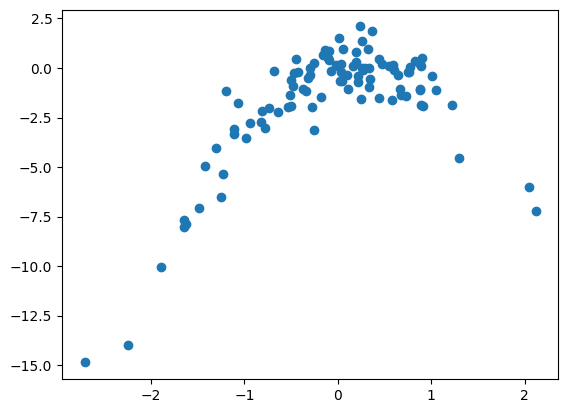

In [170]:
plt.scatter(x,y)

(c) Set a random seed, and then compute the LOOCV errors that
result from fitting the following four models using least squares:
* i. Y = β0 + β1X + "
* ii. Y = β0 + β1X + β2X2 + "
* iii. Y = β0 + β1X + β2X2 + β3X3 + "
* iv. Y = β0 + β1X + β2X2 + β3X3 + β4X4 + "

In [180]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import LeaveOneOut, cross_val_score
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression

In [186]:
loo = LeaveOneOut()
grados = [1, 2, 3, 4]
errores_loocv = []

for grado in grados:
    poly = PolynomialFeatures(degree=grado, include_bias=False)
    X_poly = poly.fit_transform(x.reshape(-1, 1))

    modelo = LinearRegression()
    mse_scores = -cross_val_score(modelo, X_poly, y, cv=loo, scoring='neg_mean_squared_error')

    mse_promedio = mse_scores.mean()
    errores_loocv.append(mse_promedio)
print(errores_loocv)

[np.float64(6.633029839181983), np.float64(1.1229368563419673), np.float64(1.3017965489358863), np.float64(1.3323942694179312)]


(d) Repeat (c) using another random seed, and report your results.
Are your results the same as what you got in (c)? Why
* No cambiare la semilla porque no exuste ninigun proceso aleatorio en este procedimiento

(e) Which of the models in (c) had the smallest LOOCV error? Is
this what you expected? Explain your answer.

El modelo de grado dos es aquel que menor error cuadratico posee

f) Comment on the statistical significance of the coefficient estimates that results from fitting each of the models in (c) using
least squares. Do these results agree with the conclusions drawn
based on the cross-validation results?

In [188]:
#aprovechamos la función de p-values que ofrece stats model
import statsmodels.api as sm

In [190]:
X1 = sm.add_constant(x)
mod1 = sm.OLS(y, X1).fit()
print(mod1.pvalues)

X2_grado = np.column_stack((x, x**2))
X2 = sm.add_constant(X2_grado)
mod2 = sm.OLS(y, X2).fit()

print(mod2.pvalues)

X3_grado = np.column_stack((x, x**2, x**3))
X3 = sm.add_constant(X3_grado)
mod3 = sm.OLS(y, X3).fit()
print(mod3.pvalues)

X4_grado = np.column_stack((x, x**2, x**3, x**4))
X4 = sm.add_constant(X4_grado)
mod4 = sm.OLS(y, X4).fit()
print(mod4.pvalues)

[4.40962098e-08 1.03650624e-09]
[5.42824291e-01 1.49491271e-11 1.34006777e-39]
[6.34501501e-01 4.44851557e-08 3.96890554e-37 2.87201831e-01]
[4.59605334e-01 2.59129629e-05 2.39602593e-19 6.42490980e-01
 2.31066104e-02]


a diferencia de los coeficientes de grados mayores el cuadratico posee mayor validación estadística

**9. We will now consider the Boston housing data set, from the ISLP
library.**

In [191]:
dt = files.upload()


Saving Boston Housing Dataset 1978.xlsx to Boston Housing Dataset 1978.xlsx


In [192]:
df = pd.read_excel('Boston Housing Dataset 1978.xlsx')


In [239]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


(a) Based on this data set, provide an estimate for the population
mean of medv. Call this estimate µˆ.

In [198]:
miu_estimada = df['MEDV'].mean()
miu_estimada

np.float64(23.750442477876106)

(b) Provide an estimate of the standard error of µˆ. Interpret this
result.


In [205]:
#Hint: We can compute the standard error of the sample mean by
#dividing the sample standard deviation by the square root of the
#number of observations.
sd_estimado = df['MEDV'].std()
n = len(df)
se_estimado = sd_estimado / np.sqrt(n)
se_estimado

np.float64(0.3915901080014807)

(c) Now estimate the standard error of µˆ using the bootstrap. How
does this compare to your answer from (b)?

In [220]:
B = 10000
boot_means = np.zeros(B)

for i in range(B):
    muestra = np.random.choice(df['MEDV'], size=n, replace=True)
    boot_means[i] = np.nanmean(muestra)

se_boot_mean = boot_means.std(ddof=1)
se_boot_mean

np.float64(0.4145674327501829)

(d) Based on your bootstrap estimate from (c), provide a 95 % confidence interval for the mean of medv. Compare it to the results
obtained by using Boston['medv'].std() and the two standard
error rule (3.9).

In [222]:
ic_bootrap = [miu_estimada - 2 * se_boot_mean, miu_estimada + 2 * se_boot_mean]
ic_teorico = [miu_estimada - 2 * se_estimado, miu_estimada + 2 * se_estimado]

In [223]:
ic_bootrap

[np.float64(22.92130761237574), np.float64(24.57957734337647)]

In [224]:
ic_teorico

[np.float64(22.967262261873145), np.float64(24.533622693879067)]

(e) Based on this data set, provide an estimate, µˆmed, for the median
value of medv in the population.


In [226]:
mu_med = df['MEDV'].median()
mu_med


21.95

f) We now would like to estimate the standard error of µˆmed. Unfortunately, there is no simple formula for computing the standard
error of the median. Instead, estimate the standard error of the
median using the bootstrap. Comment on your findings.

In [233]:
B = 1000
boot_mediana = np.zeros(B)
for i in range(B):
    muestra = np.random.choice(df['MEDV'], size=n, replace=True)
    boot_mediana[i] = np.nanmedian(muestra)

se_boot_mediana = boot_mediana.std(ddof=1)

In [234]:
se_boot_mediana

np.float64(0.2995461364930084)

(g) Based on this data set, provide an estimate for the tenth percentile of medv in Boston census tracts. Call this quantity µˆ0.1.
(You can use the np.percentile() function.)

In [238]:
mu_01 = np.nanpercentile(df['MEDV'], 10)
mu_01

np.float64(14.5)

(h) Use the bootstrap to estimate the standard error of µˆ0.1. Comment on your findings.

In [248]:
B = 1000
boots_percentil = np.zeros(B)
for i in range(B):
    muestra = np.random.choice(df['MEDV'], size=n, replace=True)
    boots_percentil[i] = np.nanpercentile(muestra,10)

se_boots_percentil = boots_percentil.std(ddof=1)

In [249]:
se_boots_percentil


np.float64(0.4169863325116322)